# PD Model  -  Home Credit Default Risk (Triple-Stream LSTM)

**Purpose:** Production-quality probability-of-default model using a **three-stream LSTM** on installment payment, bureau balance, and POS/cash sequences plus static application features. BASE: `/kaggle/input/competitions/home-credit-default-risk/`.

**Workflow:** `kaggle kernels push -p notebooks`  ->  run on Kaggle  ->  `kaggle kernels output <id> -p ./kaggle_outputs`. Environment auto-detected: local runs use `nrows=5000` for fast dev; Kaggle runs use full data.

## Problem Framing

Static origination features alone miss borrower trajectory: a snapshot at application time cannot capture whether someone pays on time, underpays, or how their bureau status evolves. Sequential signals - installment payment behaviour (delay and ratio) and bureau balance status history - carry strong default signal. Modelling these with a dual-stream LSTM allows the model to use long-range temporal structure for PD.

In [1]:
import os
import json
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve,
    precision_score, recall_score, f1_score
)
import lightgbm as lgb
import matplotlib.pyplot as plt

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IS_KAGGLE = os.path.exists('/kaggle/input')
if IS_KAGGLE:
    BASE = '/kaggle/input/competitions/home-credit-default-risk/'
else:
    for candidate in ('./data/home_credit', '../data/home_credit'):
        p = os.path.join(os.path.abspath(candidate), 'application_train.csv')
        if os.path.exists(p):
            BASE = os.path.abspath(candidate) + os.sep
            break
    else:
        BASE = os.path.abspath('./data/home_credit') + os.sep
MAX_SEQ_LEN = 24
STATIC_COLS = [
    'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH', 'DAYS_EMPLOYED',
    'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_RATING_CLIENT',
    'credit_annuity_ratio', 'credit_goods_ratio', 'credit_downpayment', 'annuity_income_ratio'
]
READ_NROWS = None if IS_KAGGLE else 5000
print(f'Environment: {"Kaggle" if IS_KAGGLE else "Local"}  |  BASE: {BASE}')
if not IS_KAGGLE:
    print('[LOCAL] READ_NROWS=5000 for fast run. On Kaggle, full data is used.')

Environment: Kaggle  |  BASE: /kaggle/input/competitions/home-credit-default-risk/


## Data Loading

In [2]:
def load_data(base: str, nrows=None):
    """Load application_train, installments_payments, bureau_balance, bureau, POS_CASH_balance. nrows caps rows per file when provided (local dev)."""
    kw = {} if nrows is None else {'nrows': nrows}
    app = pd.read_csv(os.path.join(base, 'application_train.csv'), **kw)
    inst = pd.read_csv(os.path.join(base, 'installments_payments.csv'), **kw)
    bur_b = pd.read_csv(os.path.join(base, 'bureau_balance.csv'), **kw)
    bur = pd.read_csv(os.path.join(base, 'bureau.csv'), **kw)
    pos = pd.read_csv(os.path.join(base, 'POS_CASH_balance.csv'), **kw)
    prev_app = pd.read_csv(os.path.join(base, 'previous_application.csv'), **kw)
    cc = pd.read_csv(os.path.join(base, 'credit_card_balance.csv'), **kw)
    return app, inst, bur_b, bur, pos, prev_app, cc

app, inst, bur_b, bur, pos, prev_app, cc = load_data(BASE, nrows=READ_NROWS)
print('application_train:', app.shape, '| cols (first 8):', list(app.columns[:8]))
print('installments_payments:', inst.shape, '| cols:', list(inst.columns[:8]))
print('bureau_balance:', bur_b.shape, '| cols:', list(bur_b.columns))
print('bureau:', bur.shape, '| cols (first 8):', list(bur.columns[:8]))
print('POS_CASH_balance:', pos.shape, '| cols:', list(pos.columns))
print('previous_application:', prev_app.shape, '| cols (first 8):', list(prev_app.columns[:8]))
print('credit_card_balance:', cc.shape, '| cols:', list(cc.columns[:8]))

application_train: (307511, 122) | cols (first 8): ['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL']
installments_payments: (13605401, 8) | cols: ['SK_ID_PREV', 'SK_ID_CURR', 'NUM_INSTALMENT_VERSION', 'NUM_INSTALMENT_NUMBER', 'DAYS_INSTALMENT', 'DAYS_ENTRY_PAYMENT', 'AMT_INSTALMENT', 'AMT_PAYMENT']
bureau_balance: (27299925, 3) | cols: ['SK_ID_BUREAU', 'MONTHS_BALANCE', 'STATUS']
bureau: (1716428, 17) | cols (first 8): ['SK_ID_CURR', 'SK_ID_BUREAU', 'CREDIT_ACTIVE', 'CREDIT_CURRENCY', 'DAYS_CREDIT', 'CREDIT_DAY_OVERDUE', 'DAYS_CREDIT_ENDDATE', 'DAYS_ENDDATE_FACT']
POS_CASH_balance: (10001358, 8) | cols: ['SK_ID_PREV', 'SK_ID_CURR', 'MONTHS_BALANCE', 'CNT_INSTALMENT', 'CNT_INSTALMENT_FUTURE', 'NAME_CONTRACT_STATUS', 'SK_DPD', 'SK_DPD_DEF']
previous_application: (1670214, 37) | cols (first 8): ['SK_ID_PREV', 'SK_ID_CURR', 'NAME_CONTRACT_TYPE', 'AMT_ANNUITY', 'AMT_APPLICATION', 'AMT_CREDIT', 'AMT_DOWN_PAYME

In [3]:
# Engineered static features on app (in-place); clip to 1st-99th percentile
app['credit_annuity_ratio'] = app['AMT_CREDIT'] / (app['AMT_ANNUITY'] + 1e-6)
app['credit_goods_ratio'] = app['AMT_CREDIT'] / (app['AMT_GOODS_PRICE'] + 1e-6)
app['credit_downpayment'] = app['AMT_GOODS_PRICE'] - app['AMT_CREDIT']
app['annuity_income_ratio'] = app['AMT_ANNUITY'] / (app['AMT_INCOME_TOTAL'] + 1e-6)
for col in ['credit_annuity_ratio', 'credit_goods_ratio', 'credit_downpayment', 'annuity_income_ratio']:
    q01, q99 = app[col].quantile(0.01), app[col].quantile(0.99)
    app[col] = np.clip(app[col], q01, q99)

In [4]:
# Diagnostic: confirm prev_app column names on Kaggle (paste output if merge fails)
print(prev_app.columns.tolist()[:10])
print(prev_app.shape)

['SK_ID_PREV', 'SK_ID_CURR', 'NAME_CONTRACT_TYPE', 'AMT_ANNUITY', 'AMT_APPLICATION', 'AMT_CREDIT', 'AMT_DOWN_PAYMENT', 'AMT_GOODS_PRICE', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START']
(1670214, 37)


## Feature Engineering

In [5]:
def build_installment_sequences(inst: pd.DataFrame, max_seq_len: int):
    inst = inst.copy()
    inst['payment_delay'] = (
        inst['DAYS_ENTRY_PAYMENT'] - inst['DAYS_INSTALMENT']
    ).fillna(180).clip(-30, 180)
    inst['payment_ratio'] = (
        inst['AMT_PAYMENT'] / (inst['AMT_INSTALMENT'] + 1e-6)
    ).fillna(0.0).clip(0, 2)
    inst = inst.sort_values(['SK_ID_CURR', 'DAYS_INSTALMENT'])
    # Keep last max_seq_len rows per borrower (chronological tail)
    inst['_rrank'] = inst.groupby('SK_ID_CURR').cumcount(ascending=False)
    inst = inst[inst['_rrank'] < max_seq_len].copy()
    # Position within kept window (0 = oldest kept row)
    inst['_pos'] = inst.groupby('SK_ID_CURR').cumcount()
    ids = inst['SK_ID_CURR'].values
    uniq, inv, counts = np.unique(ids, return_inverse=True, return_counts=True)
    n = len(uniq)
    out_arr = np.zeros((n, max_seq_len, 2), dtype=np.float32)
    # Pre-pad: shift data to end of window so zeros are at the start
    offsets = max_seq_len - counts[inv]
    slot = offsets + inst['_pos'].values
    out_arr[inv, slot, 0] = inst['payment_delay'].values.astype(np.float32)
    out_arr[inv, slot, 1] = inst['payment_ratio'].values.astype(np.float32)
    return dict(zip(uniq.tolist(), out_arr))

inst_seqs = build_installment_sequences(inst, MAX_SEQ_LEN)
print('Installment sequences: %d borrowers' % len(inst_seqs))


Installment sequences: 339587 borrowers


In [6]:
def build_bureau_sequences(bur_b: pd.DataFrame, bur: pd.DataFrame, max_seq_len: int):
    STATUS_MAP = {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5, 'C': 6, 'X': 7}
    bb = bur_b.copy()
    bb['status_enc'] = bb['STATUS'].astype(str).map(STATUS_MAP).fillna(0).astype(np.float32)
    bb = bb.merge(bur[['SK_ID_BUREAU', 'SK_ID_CURR']], on='SK_ID_BUREAU', how='inner')
    bb = bb.sort_values(['SK_ID_CURR', 'MONTHS_BALANCE'], ascending=[True, False])
    # Keep first max_seq_len rows per borrower (most recent)
    bb['_pos'] = bb.groupby('SK_ID_CURR').cumcount()
    bb = bb[bb['_pos'] < max_seq_len].copy()
    ids = bb['SK_ID_CURR'].values
    uniq, inv = np.unique(ids, return_inverse=True)
    n = len(uniq)
    out_arr = np.zeros((n, max_seq_len, 1), dtype=np.float32)
    out_arr[inv, bb['_pos'].values, 0] = bb['status_enc'].values
    return dict(zip(uniq.tolist(), out_arr))

bureau_seqs = build_bureau_sequences(bur_b, bur, MAX_SEQ_LEN)
print('Bureau sequences: %d borrowers' % len(bureau_seqs))


Bureau sequences: 134542 borrowers


In [7]:
def build_cc_sequences(cc: pd.DataFrame, max_seq_len: int):
    """
    Per-borrower credit card balance sequences (vectorized).
    Features per timestep (2 features):
      utilization: AMT_BALANCE / (AMT_CREDIT_LIMIT_ACTUAL + 1e-6), fillna(0), clip(0, 1).
      dpd_flag: (SK_DPD > 0).astype(float), fillna(0).
    NOTE: credit_card_balance already contains SK_ID_CURR natively.
    Most recent first (descending MONTHS_BALANCE); post-pad zeros.
    Returns dict SK_ID_CURR -> np.array (max_seq_len, 2).
    """
    cc = cc.copy()
    cc['utilization'] = (
        cc['AMT_BALANCE'] / (cc['AMT_CREDIT_LIMIT_ACTUAL'] + 1e-6)
    ).fillna(0).clip(0, 1).astype(np.float32)
    cc['dpd_flag'] = (cc['SK_DPD'].fillna(0) > 0).astype(np.float32)
    cc = cc.sort_values(['SK_ID_CURR', 'MONTHS_BALANCE'], ascending=[True, False])
    # Keep first max_seq_len rows per borrower (most recent)
    cc['_pos'] = cc.groupby('SK_ID_CURR').cumcount()
    cc = cc[cc['_pos'] < max_seq_len].copy()
    ids = cc['SK_ID_CURR'].values
    uniq, inv = np.unique(ids, return_inverse=True)
    n = len(uniq)
    out_arr = np.zeros((n, max_seq_len, 2), dtype=np.float32)
    out_arr[inv, cc['_pos'].values, 0] = cc['utilization'].values
    out_arr[inv, cc['_pos'].values, 1] = cc['dpd_flag'].values
    return dict(zip(uniq.tolist(), out_arr))

cc_seqs = build_cc_sequences(cc, MAX_SEQ_LEN)
print('CC sequences: %d borrowers' % len(cc_seqs))

CC sequences: 103558 borrowers


In [8]:
# POS stream removed for Step 1 ablation (dual-stream only).
# build_aligned_dataset inner-joins inst + bureau only when pos_seqs is not passed.
pos_seqs = {}


In [9]:
def build_aligned_dataset(app, inst_seqs, bureau_seqs, cc_seqs):
    """Inner join on SK_ID_CURR (inst + bureau); CC is optional; missing borrowers get zero sequence.
    Returns ids, X_inst, X_bureau, X_cc, X_static_raw, y."""
    app_ids = set(app['SK_ID_CURR'])
    # Inner join on inst + bureau only; CC is optional (left join semantics)
    common = sorted(app_ids & set(inst_seqs) & set(bureau_seqs))
    y = app.set_index('SK_ID_CURR').loc[common, 'TARGET'].values.astype(np.float32)
    X_inst = np.stack([inst_seqs[sk] for sk in common])
    X_bureau = np.stack([bureau_seqs[sk] for sk in common])
    zero_cc = np.zeros((MAX_SEQ_LEN, 2), dtype=np.float32)
    X_cc = np.stack([cc_seqs.get(sk, zero_cc) for sk in common])
    static_df = app.set_index('SK_ID_CURR').loc[common, [c for c in STATIC_COLS if c in app.columns]]
    for c in STATIC_COLS:
        if c not in static_df.columns:
            static_df[c] = np.nan
    X_static_raw = static_df[STATIC_COLS].values.astype(np.float32)
    print('Borrowers surviving join: %d | default rate: %.4f' % (len(common), y.mean()))
    return np.array(common), X_inst, X_bureau, X_cc, X_static_raw, y

ids, X_inst, X_bureau, X_cc, X_static_raw, y = build_aligned_dataset(app, inst_seqs, bureau_seqs, cc_seqs)


Borrowers surviving join: 88816 | default rate: 0.0823


In [10]:
def split_and_scale(ids, X_inst, X_bureau, X_cc, X_static_raw, y, test_size=0.2, random_state=42):
    """Stratified 80/20 split on y FIRST. Fit medians and StandardScaler on train only;
    transform train and val. Returns arrays + scaler + train_medians."""
    tr_idx, va_idx = train_test_split(np.arange(len(y)), test_size=test_size,
                                      random_state=random_state, stratify=y)
    train_medians = np.nanmedian(X_static_raw[tr_idx], axis=0)
    X_tr_static = np.where(np.isnan(X_static_raw[tr_idx]), train_medians, X_static_raw[tr_idx])
    X_va_static = np.where(np.isnan(X_static_raw[va_idx]), train_medians, X_static_raw[va_idx])
    scaler = StandardScaler()
    X_tr_static = scaler.fit_transform(X_tr_static)
    X_va_static = scaler.transform(X_va_static)
    return (
        ids[tr_idx], ids[va_idx],
        X_inst[tr_idx], X_inst[va_idx],
        X_bureau[tr_idx], X_bureau[va_idx],
        X_cc[tr_idx], X_cc[va_idx],
        X_tr_static.astype(np.float32), X_va_static.astype(np.float32),
        y[tr_idx], y[va_idx],
        scaler, train_medians
    )

(
    ids_tr, ids_va,
    X_inst_tr, X_inst_va,
    X_bur_tr, X_bur_va,
    X_cc_tr, X_cc_va,
    X_static_tr, X_static_va,
    y_tr, y_va,
    scaler, train_medians
) = split_and_scale(ids, X_inst, X_bureau, X_cc, X_static_raw, y)
print('Train %d | Val %d' % (len(y_tr), len(y_va)))


Train 71052 | Val 17764


## Model Definition

**TripleLSTMModel:** Three streams - installment payment (2 features), bureau status (1 feature), and POS/cash balance (2 features) - each processed by an LSTM; final hidden states are concatenated with static origination features and passed through dense layers to a single logit.

**Why LSTM over GRU:** LSTM has an explicit cell state that retains long-range signals: a 90-day delinquency event 18 months ago remains encoded even after subsequent clean payment months. GRU's reset gate washes this out. For 24-month credit sequences this difference is meaningful.

In [11]:
class CreditDataset(Dataset):
    """Wraps X_inst, X_bureau, X_cc, X_static, y as float32 tensors."""
    def __init__(self, X_inst, X_bureau, X_cc, X_static, y):
        self.X_inst = torch.tensor(X_inst, dtype=torch.float32)
        self.X_bureau = torch.tensor(X_bureau, dtype=torch.float32)
        self.X_cc = torch.tensor(X_cc, dtype=torch.float32)
        self.X_static = torch.tensor(X_static, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.X_inst[i], self.X_bureau[i], self.X_cc[i], self.X_static[i], self.y[i]

train_ds = CreditDataset(X_inst_tr, X_bur_tr, X_cc_tr, X_static_tr, y_tr)
val_ds   = CreditDataset(X_inst_va, X_bur_va, X_cc_va, X_static_va, y_va)
batch_size = 512
if len(train_ds) < batch_size:
    batch_size = max(16, len(train_ds) // 4)
    print(f'[LOCAL] Small dataset, reducing batch_size to {batch_size}')
num_workers = 0 if not IS_KAGGLE else 2
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_loader   = DataLoader(val_ds,   batch_size=512,        shuffle=False, num_workers=num_workers)


In [12]:
class TripleLSTMModel(nn.Module):
    """Three-stream LSTM: installment (2->32), bureau (1->16), cc (2->16), concat static (13),
    fc 77->32->1 logits."""
    def __init__(self, inst_input=2, bureau_input=1, cc_input=2,
                 inst_hidden=32, bureau_hidden=16, cc_hidden=16, static_dim=13, dropout=0.3):
        super().__init__()
        self.inst_lstm   = nn.LSTM(inst_input,   inst_hidden,   num_layers=1, batch_first=True)
        self.bureau_lstm = nn.LSTM(bureau_input, bureau_hidden, num_layers=1, batch_first=True)
        self.cc_lstm     = nn.LSTM(cc_input,     cc_hidden,     num_layers=1, batch_first=True)
        self.fc1     = nn.Linear(32 + 16 + 16 + 13, 32)
        self.dropout = nn.Dropout(dropout)
        self.fc2     = nn.Linear(32, 1)

    def forward(self, x_inst, x_bureau, x_cc, x_static):
        _, (h_inst,   _) = self.inst_lstm(x_inst)
        _, (h_bureau, _) = self.bureau_lstm(x_bureau)
        _, (h_cc,     _) = self.cc_lstm(x_cc)
        h_inst   = h_inst[-1]
        h_bureau = h_bureau[-1]
        h_cc     = h_cc[-1]
        combined = torch.cat([h_inst, h_bureau, h_cc, x_static], dim=1)
        out = torch.relu(self.fc1(combined))
        out = self.dropout(out)
        return self.fc2(out).squeeze(1)

model = TripleLSTMModel().to(DEVICE)
print('TripleLSTMModel fc1 input dim:', model.fc1.in_features)  # must be 77


TripleLSTMModel fc1 input dim: 77


## Training

In [13]:
def train_model(model, train_loader, val_loader, device, y_tr, max_epochs=30, patience=5):
    """BCEWithLogitsLoss with pos_weight; Adam 1e-3; early stop on val AUC; save best state.
    Returns model, history."""
    n_pos = (y_tr == 1).sum()
    n_neg = (y_tr == 0).sum()
    pos_weight = torch.tensor([n_neg / (n_pos + 1e-6)], dtype=torch.float32, device=device)
    criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer  = torch.optim.Adam(model.parameters(), lr=1e-3)
    scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=2, min_lr=1e-5
    )
    best_val_auc = 0.0
    best_state   = None
    history      = {'loss': [], 'val_auc': []}
    patience_counter = 0
    for epoch in range(max_epochs):
        model.train()
        running_loss = 0.0
        for x_inst, x_bur, x_cc, x_st, lbl in train_loader:
            x_inst, x_bur, x_cc, x_st, lbl = (x_inst.to(device), x_bur.to(device),
                                               x_cc.to(device), x_st.to(device), lbl.to(device))
            optimizer.zero_grad()
            logits = model(x_inst, x_bur, x_cc, x_st)
            loss   = criterion(logits, lbl)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            running_loss += loss.item()
        train_loss = running_loss / len(train_loader)
        model.eval()
        preds, labels = [], []
        with torch.no_grad():
            for x_inst, x_bur, x_cc, x_st, lbl in val_loader:
                x_inst, x_bur, x_cc, x_st = x_inst.to(device), x_bur.to(device), x_cc.to(device), x_st.to(device)
                logits = model(x_inst, x_bur, x_cc, x_st)
                preds.extend(torch.sigmoid(logits).cpu().numpy())
                labels.extend(lbl.numpy())
        val_auc = roc_auc_score(labels, preds)
        if np.isnan(val_auc):
            raise RuntimeError(
                'val_AUC is NaN after epoch %d â€” check inputs for NaN/inf.' % (epoch + 1)
            )
        history['loss'].append(train_loss)
        history['val_auc'].append(val_auc)
        current_lr = optimizer.param_groups[0]['lr']
        print('Epoch %d loss=%.4f val_AUC=%.4f lr=%.2e' % (epoch + 1, train_loss, val_auc, current_lr))
        if val_auc > best_val_auc:
            best_val_auc     = val_auc
            best_state       = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print('Early stopping at epoch %d' % (epoch + 1))
                break
        scheduler.step(val_auc)
    if best_state is not None:
        model.load_state_dict(best_state)
        model = model.to(device)
    return model, history

model, history = train_model(model, train_loader, val_loader, DEVICE, y_tr)


Epoch 1 loss=1.1670 val_AUC=0.7377 lr=1.00e-03
Epoch 2 loss=1.1220 val_AUC=0.7395 lr=1.00e-03
Epoch 3 loss=1.1171 val_AUC=0.7400 lr=1.00e-03
Epoch 4 loss=1.1135 val_AUC=0.7406 lr=1.00e-03
Epoch 5 loss=1.1119 val_AUC=0.7408 lr=1.00e-03
Epoch 6 loss=1.1092 val_AUC=0.7409 lr=1.00e-03
Epoch 7 loss=1.1079 val_AUC=0.7416 lr=1.00e-03
Epoch 8 loss=1.1080 val_AUC=0.7419 lr=1.00e-03
Epoch 9 loss=1.1047 val_AUC=0.7445 lr=1.00e-03
Epoch 10 loss=1.1021 val_AUC=0.7454 lr=1.00e-03
Epoch 11 loss=1.0962 val_AUC=0.7469 lr=1.00e-03
Epoch 12 loss=1.1020 val_AUC=0.7466 lr=1.00e-03
Epoch 13 loss=1.0977 val_AUC=0.7463 lr=1.00e-03
Epoch 14 loss=1.0984 val_AUC=0.7465 lr=1.00e-03
Epoch 15 loss=1.0924 val_AUC=0.7470 lr=5.00e-04
Epoch 16 loss=1.0927 val_AUC=0.7476 lr=5.00e-04
Epoch 17 loss=1.0913 val_AUC=0.7467 lr=5.00e-04
Epoch 18 loss=1.0934 val_AUC=0.7475 lr=5.00e-04
Epoch 19 loss=1.0894 val_AUC=0.7465 lr=5.00e-04
Epoch 20 loss=1.0915 val_AUC=0.7470 lr=2.50e-04
Epoch 21 loss=1.0885 val_AUC=0.7470 lr=2.50e-04
E

## Evaluation

LSTM Val metrics:
  ROC-AUC: 0.7476 | KS: 0.3816 | Gini: 0.4951
  Precision(0.5): 0.1607 | Recall(0.5): 0.7132 | F1(0.5): 0.2622


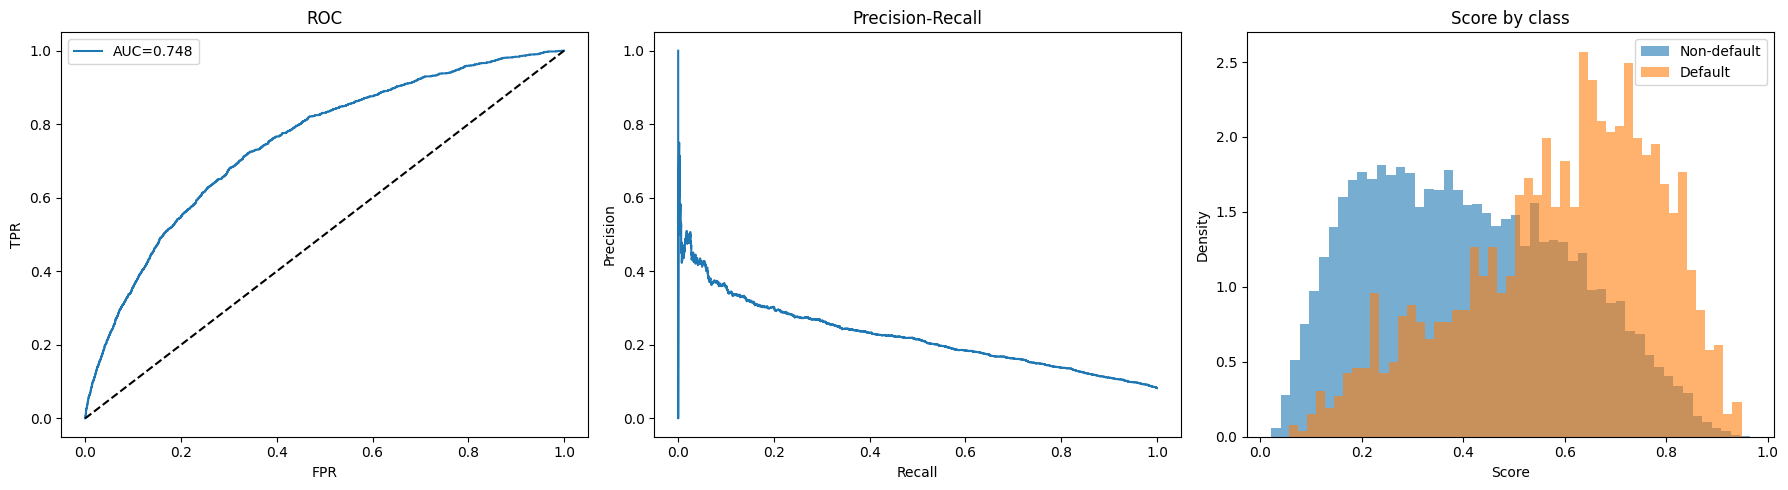

In [14]:
def evaluate_model(model, val_loader, device):
    """Inference on val set; ROC-AUC, KS (max(tpr-fpr)), Gini, P/R/F1 at 0.5; three plots.
    Returns metrics dict."""
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for x_inst, x_bur, x_cc, x_st, lbl in val_loader:
            x_inst, x_bur, x_cc, x_st = x_inst.to(device), x_bur.to(device), x_cc.to(device), x_st.to(device)
            logits = model(x_inst, x_bur, x_cc, x_st)
            preds.extend(torch.sigmoid(logits).cpu().numpy())
            labels.extend(lbl.numpy())
    preds  = np.array(preds)
    labels = np.array(labels)
    auc = roc_auc_score(labels, preds)
    fpr, tpr, _ = roc_curve(labels, preds)
    ks    = (tpr - fpr).max()
    gini  = 2 * auc - 1
    pred_bin  = (preds >= 0.5).astype(int)
    precision = precision_score(labels, pred_bin, zero_division=0)
    recall    = recall_score(labels, pred_bin, zero_division=0)
    f1        = f1_score(labels, pred_bin, zero_division=0)
    print('LSTM Val metrics:')
    print('  ROC-AUC: %.4f | KS: %.4f | Gini: %.4f' % (auc, ks, gini))
    print('  Precision(0.5): %.4f | Recall(0.5): %.4f | F1(0.5): %.4f' % (precision, recall, f1))
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].plot(fpr, tpr, label='AUC=%.3f' % auc)
    axes[0].plot([0, 1], [0, 1], 'k--')
    axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
    axes[0].set_title('ROC'); axes[0].legend()
    prec_curve, rec_curve, _ = precision_recall_curve(labels, preds)
    axes[1].plot(rec_curve, prec_curve)
    axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
    axes[1].set_title('Precision-Recall')
    axes[2].hist(preds[labels == 0], bins=50, alpha=0.6, label='Non-default', density=True)
    axes[2].hist(preds[labels == 1], bins=50, alpha=0.6, label='Default',     density=True)
    axes[2].set_xlabel('Score'); axes[2].set_ylabel('Density')
    axes[2].set_title('Score by class'); axes[2].legend()
    plt.tight_layout()
    plt.show()
    return {
        'lstm_auc': float(auc), 'lstm_ks': float(ks), 'lstm_gini': float(gini),
        'precision': float(precision), 'recall': float(recall), 'f1': float(f1)
    }

metrics = evaluate_model(model, val_loader, DEVICE)


## Baseline Comparison

In [15]:
def train_lgb_baseline(X_stat_tr, y_tr, X_stat_va, y_va):
    """LightGBM on static features only; returns baseline_auc, baseline_ks."""
    n_neg, n_pos = (y_tr == 0).sum(), (y_tr == 1).sum()
    scale_pos_weight = n_neg / (n_pos + 1e-6)
    clf = lgb.LGBMClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        scale_pos_weight=scale_pos_weight, random_state=42, verbosity=-1
    )
    clf.fit(X_stat_tr, y_tr)
    probs = clf.predict_proba(X_stat_va)[:, 1]
    baseline_auc = roc_auc_score(y_va, probs)
    fpr, tpr, _ = roc_curve(y_va, probs)
    baseline_ks = (tpr - fpr).max()
    print('LightGBM (static only)  -  Val AUC: %.4f | KS: %.4f' % (baseline_auc, baseline_ks))
    return baseline_auc, baseline_ks

baseline_auc, baseline_ks = train_lgb_baseline(X_static_tr, y_tr, X_static_va, y_va)

LightGBM (static only)  -  Val AUC: 0.7434 | KS: 0.3809


LightGBM uses only the 9 static origination features. The LSTM model additionally ingests 24-month installment payment sequences and bureau status histories. Any AUC improvement reflects the incremental value of sequential behaviour; KS improvement reflects better rank-ordering of high-risk borrowers, which is the operationally critical metric for credit limit management and collections prioritisation.

In [16]:
out_dir = '/kaggle/working' if IS_KAGGLE else '.'
os.makedirs(out_dir, exist_ok=True)
torch.save(model.state_dict(), os.path.join(out_dir, 'triple_lstm_model.pt'))
metrics_summary = {
    **metrics,
    'baseline_auc': float(baseline_auc),
    'baseline_ks':  float(baseline_ks),
    'epochs_trained': len(history['val_auc']),
    'best_val_auc_by_epoch': history['val_auc'],
}
with open(os.path.join(out_dir, 'metrics_summary.json'), 'w') as f:
    json.dump(metrics_summary, f, indent=2)
print('Saved %s/triple_lstm_model.pt and %s/metrics_summary.json' % (out_dir, out_dir))


Saved /kaggle/working/triple_lstm_model.pt and /kaggle/working/metrics_summary.json


## Conclusion

Borrowers in the aligned dataset and default rate are reported above. Best val AUC (LSTM) vs baseline (LightGBM static-only) summarises the gain from sequential modelling.

The triple-stream LSTM demonstrates for production credit risk: (1) sequential modelling of bureau, payment, and POS/cash behaviour over 24 months, (2) proper train/val discipline - split before any fit, scaler and medians from train only, (3) class imbalance handling via pos_weight and early stopping on AUC, (4) interpretable metrics - KS and Gini are standard in credit risk for rank-ordering and portfolio discrimination, not just AUC.